**Amazon Product Review Sentiment Classification using BERT
Project Overview**

In this project, we build a three-class sentiment classifier (Positive / Neutral / Negative) on real Amazon product reviews using BERT (Bidirectional Encoder Representations from Transformers).

BERT is a state-of-the-art pre-trained language model developed by Google. Fine-tuning BERT on a downstream task like sentiment classification allows us to achieve high accuracy even with relatively small datasets.

Sentiment Label Mapping

In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

**Dataset: Amazon India Product Reviews (amazon.csv)**
for sentiment analysis , Online Retail
Model: bert-base-uncased via HuggingFace Transformers

In [ ]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528415 entries, 0 to 528414
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    399459 non-null  object        
 1   StockCode    399459 non-null  object        
 2   Description  398133 non-null  object        
 3   Quantity     399459 non-null  float64       
 4   InvoiceDate  399459 non-null  datetime64[ns]
 5   UnitPrice    399459 non-null  float64       
 6   CustomerID   296646 non-null  float64       
 7   Country      399459 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 32.3+ MB


,0
InvoiceNo,128956
StockCode,128956
Description,130282
Quantity,128956
InvoiceDate,128956
UnitPrice,128956
CustomerID,231769
Country,128956


**Data Cleaning**

In [ ]:
df = df.dropna(subset=['CustomerID', 'Description'])

In [ ]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

In [ ]:
df = df[df['Quantity'] > 0]

In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df['Description'] = df['Description'].str.lower()
df['Description'] = df['Description'].str.strip()

In [ ]:
df.rename(columns={
    'CustomerID': 'user_id',
    'Description': 'product_name',
    'UnitPrice': 'price'
}, inplace=True)

In [ ]:
df = df[['user_id', 'InvoiceNo', 'product_name', 'Quantity', 'price', 'Country']]

In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 289527 entries, 0 to 528095
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   user_id       289527 non-null  int64  
 1   InvoiceNo     289527 non-null  object 
 2   product_name  289527 non-null  object 
 3   Quantity      289527 non-null  float64
 4   price         289527 non-null  float64
 5   Country       289527 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 15.5+ MB


,user_id,InvoiceNo,product_name,Quantity,price,Country
0,17850,536365,white hanging heart t-light holder,6.0,2.55,United Kingdom
1,17850,536365,white metal lantern,6.0,3.39,United Kingdom
2,17850,536365,cream cupid hearts coat hanger,8.0,2.75,United Kingdom
3,17850,536365,knitted union flag hot water bottle,6.0,3.39,United Kingdom
4,17850,536365,red woolly hottie white heart.,6.0,3.39,United Kingdom


Transaction Dataset

In [ ]:
transactions = df.groupby('InvoiceNo')['product_name'].apply(list)

In [ ]:
transactions.head()

,product_name
InvoiceNo,
536365,"[white hanging heart t-light holder, white met..."
536366,"[hand warmer union jack, hand warmer red polka..."
536367,"[assorted colour bird ornament, poppy's playho..."
536368,"[jam making set with jars, red coat rack paris..."
536369,[bath building block word]


In [ ]:
print(len(transactions))
print(transactions.iloc[0])

14060
['white hanging heart t-light holder', 'white metal lantern', 'cream cupid hearts coat hanger', 'knitted union flag hot water bottle', 'red woolly hottie white heart.', 'set 7 babushka nesting boxes', 'glass star frosted t-light holder']


In [ ]:
print(max(len(x) for x in transactions))

529


** One-Hot Encoding**

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Convert the dataset into a list of transactions
transactions = df.groupby('InvoiceNo')['product_name'].apply(lambda x: list(set(x))).tolist()

# Initialize the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert to a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Display the encoded data
df_encoded.head()

,10 colour spaceboy pen,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 pencil small tube woodland,12 pencils small tube red retrospot,12 pencils small tube skull,12 pencils tall tube posy,...,zinc star t-light holder,zinc sweetheart soap dish,zinc sweetheart wire letter rack,zinc t-light holder star large,zinc t-light holder stars large,zinc t-light holder stars small,zinc top 2 door wooden shelf,zinc willie winkie candle stick,zinc wire kitchen organiser,zinc wire sweetheart letter tray
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_encoded.shape

(14060, 3792)

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Convert the dataset into a list of transactions
transactions = df.groupby('InvoiceNo')['product_name'].apply(lambda x: list(set(x))).tolist()

# Initialize the TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert to a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

**Apriori**

identifying frequent itemsets using support
Generating association rules using confidence and lift


Apriori Implementation

In [ ]:
from mlxtend.frequent_patterns import apriori

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

In [ ]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

In [ ]:
frequent_itemsets.head()

,support,itemsets
0,0.013016,(10 colour spaceboy pen)
1,0.013300,(12 pencils small tube red retrospot)
2,0.017141,(12 pencils small tube skull)
3,0.011664,(12 pencils tall tube posy)
4,0.011309,(12 pencils tall tube red retrospot)


Association Rules

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(pack of 72 retrospot cake cases),(60 cake cases dolly girl design),0.060811,0.019772,0.010669,0.175439,8.872902,1.0,0.009466,1.188787,0.944748,0.152594,0.158806,0.357503
1,(60 cake cases dolly girl design),(pack of 72 retrospot cake cases),0.019772,0.060811,0.010669,0.539568,8.872902,1.0,0.009466,2.039802,0.905195,0.152594,0.509756,0.357503
2,(72 sweetheart fairy cake cases),(60 teatime fairy cake cases),0.028521,0.038407,0.012518,0.438903,11.427727,1.0,0.011422,1.713773,0.939282,0.230065,0.416492,0.382414
3,(60 teatime fairy cake cases),(72 sweetheart fairy cake cases),0.038407,0.028521,0.012518,0.325926,11.427727,1.0,0.011422,1.441206,0.948939,0.230065,0.306137,0.382414
4,(pack of 60 dinosaur cake cases),(60 teatime fairy cake cases),0.031010,0.038407,0.012802,0.412844,10.749235,1.0,0.011611,1.637713,0.935995,0.226131,0.389393,0.373089


**the best rule**

In [ ]:
rules_filtered = rules[
    (rules['lift'] > 2) &
    (rules['confidence'] > 0.3)
]

rules_filtered.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
779,(herb marker rosemary),"(herb marker mint, herb marker thyme)",0.011878,0.010597,0.010171,0.856287,80.801350,1.0,0.010045,6.884593,0.999496,0.826590,0.854748,0.908009
774,"(herb marker mint, herb marker thyme)",(herb marker rosemary),0.010597,0.011878,0.010171,0.959732,80.801350,1.0,0.010045,24.538371,0.998202,0.826590,0.959247,0.908009
784,(herb marker thyme),"(herb marker parsley, herb marker rosemary)",0.011735,0.010740,0.010171,0.866667,80.697572,1.0,0.010045,7.419452,0.999336,0.826590,0.865219,0.906843
781,"(herb marker parsley, herb marker rosemary)",(herb marker thyme),0.010740,0.011735,0.010171,0.947020,80.697572,1.0,0.010045,18.653494,0.998330,0.826590,0.946391,0.906843
780,"(herb marker parsley, herb marker thyme)",(herb marker rosemary),0.010669,0.011878,0.010171,0.953333,80.262675,1.0,0.010044,21.174050,0.998190,0.821839,0.952772,0.904810
785,(herb marker rosemary),"(herb marker parsley, herb marker thyme)",0.011878,0.010669,0.010171,0.856287,80.262675,1.0,0.010044,6.884098,0.999412,0.821839,0.854738,0.904810
767,(herb marker rosemary),"(herb marker thyme, herb marker basil)",0.011878,0.010597,0.010100,0.850299,80.236306,1.0,0.009974,6.609209,0.999407,0.816092,0.848696,0.901660
762,"(herb marker thyme, herb marker basil)",(herb marker rosemary),0.010597,0.011878,0.010100,0.953020,80.236306,1.0,0.009974,21.032890,0.998114,0.816092,0.952455,0.901660
766,(herb marker thyme),"(herb marker rosemary, herb marker basil)",0.011735,0.010740,0.010100,0.860606,80.133253,1.0,0.009974,7.096867,0.999247,0.816092,0.859093,0.900502
763,"(herb marker rosemary, herb marker basil)",(herb marker thyme),0.010740,0.011735,0.010100,0.940397,80.133253,1.0,0.009974,16.580884,0.998242,0.816092,0.939690,0.900502


**Recommendation System**

In [ ]:
def recommend_clean(product, rules, top_n=5):
    recs = rules[rules['antecedents'].apply(lambda x: product in x)]

    recs = recs.sort_values(by=['lift', 'confidence'], ascending=False)


    recs = recs.drop_duplicates(subset=['consequents'])

    return recs[['consequents', 'confidence', 'lift']].head(top_n)

**Top-N recommendations**

In [ ]:
def recommend_product(product_name):
    recs = rules_fp[rules_fp['antecedents'].apply(lambda x: product_name in x)]
    return recs.sort_values(by='confidence', ascending=False).head(5)

recommend_product("hand warmer union jack").head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


**FP-GROWTH**

The FP-Growth Algorithm is an improved version of Apriori designed for better efficiency.

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

frequent_fp = fpgrowth(df_encoded, min_support=0.01, use_colnames=True)

print(frequent_fp.head())

rules_fp = association_rules(frequent_fp, metric="lift", min_threshold=1)

print(rules_fp.head())

    support                               itemsets
0  0.114651   (white hanging heart t-light holder)
1  0.016856         (set 7 babushka nesting boxes)
2  0.015434                  (white metal lantern)
3  0.015078       (cream cupid hearts coat hanger)
4  0.014296  (knitted union flag hot water bottle)
                            antecedents                           consequents  \
0       (assorted colour bird ornament)  (white hanging heart t-light holder)   
1  (white hanging heart t-light holder)       (assorted colour bird ornament)   
2            (regency cakestand 3 tier)       (assorted colour bird ornament)   
3       (assorted colour bird ornament)            (regency cakestand 3 tier)   
4       (assorted colour bird ornament)                       (party bunting)   

   antecedent support  consequent support   support  confidence      lift  \
0            0.074680            0.114651  0.016145    0.216190  1.885632   
1            0.114651            0.074680  0.016145  

**page rank**

 to rank products or items based on their importance within a network (graph-based ranking).

In [ ]:
pip install pandas numpy matplotlib seaborn networkx mlxtend openpyxl

In [ ]:
print(df.columns)
print(df.head())
print(df.info())
print(df.isnull().sum())

Index(['user_id', 'InvoiceNo', 'product_name', 'Quantity', 'price', 'Country'], dtype='object')
   user_id InvoiceNo                         product_name  Quantity  price  \
0    17850    536365   white hanging heart t-light holder       6.0   2.55   
1    17850    536365                  white metal lantern       6.0   3.39   
2    17850    536365       cream cupid hearts coat hanger       8.0   2.75   
3    17850    536365  knitted union flag hot water bottle       6.0   3.39   
4    17850    536365       red woolly hottie white heart.       6.0   3.39   

          Country  
0  United Kingdom  
1  United Kingdom  
2  United Kingdom  
3  United Kingdom  
4  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
Index: 289527 entries, 0 to 528095
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   user_id       289527 non-null  int64  
 1   InvoiceNo     289527 non-null  object 
 2   product_name  289527 non-null

In [ ]:
df.dropna(subset=['user_id', 'product_name'], inplace=True)

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df = df[(df['Quantity'] > 0) & (df['price'] > 0)]

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['price']

In [ ]:
top_products = df.groupby('product_name')['Quantity']\
.sum().sort_values(ascending=False).head(10)

print(top_products)

product_name
medium ceramic top storage jar        77070.0
world war 2 gliders asstd designs     42056.0
jumbo bag red retrospot               37558.0
white hanging heart t-light holder    30333.0
pack of 72 retrospot cake cases       29896.0
assorted colour bird ornament         27073.0
pack of 60 pink paisley cake cases    22317.0
pack of 12 london tissues             21625.0
assorted colours silk fan             20880.0
mini paint set vintage                20673.0
Name: Quantity, dtype: float64


In [ ]:
top_countries = df.groupby('Country')['TotalPrice']\
.sum().sort_values(ascending=False).head(10)

print(top_countries)

Country
United Kingdom    5438391.044
EIRE               213419.680
Netherlands        208240.990
Germany            175029.410
France             147700.230
Australia          131211.090
Switzerland         45413.690
Spain               44359.150
Belgium             30304.220
Sweden              29879.440
Name: TotalPrice, dtype: float64


In [ ]:
top_customers = df.groupby('user_id')['InvoiceNo']\
.nunique().sort_values(ascending=False).head(10)

print(top_customers)

user_id
14911    147
12748    147
17841     96
13089     83
14606     78
15311     73
12971     69
16029     61
14646     49
18102     48
Name: InvoiceNo, dtype: int64


In [ ]:
import networkx as nx
from itertools import combinations

In [ ]:
G = nx.Graph()

In [ ]:
transactions = df.groupby('InvoiceNo')['product_name'].apply(list)

In [ ]:
for products in transactions:
    unique_products = list(set(products))

    for pair in combinations(unique_products, 2):
        if G.has_edge(*pair):
            G[pair[0]][pair[1]]['weight'] += 1
        else:
            G.add_edge(pair[0], pair[1], weight=1)

In [ ]:
pagerank_scores = nx.pagerank(G)

In [ ]:
pagerank_df = pd.DataFrame(
    pagerank_scores.items(),
    columns=['Product', 'PageRank']
).sort_values(by='PageRank', ascending=False)

print(pagerank_df.head(10))

                                 Product  PageRank
5     white hanging heart t-light holder  0.003650
521             regency cakestand 3 tier  0.002958
73               lunch bag red retrospot  0.002799
136              jumbo bag red retrospot  0.002666
1380                       party bunting  0.002612
58       pack of 72 retrospot cake cases  0.002457
2138    set of 3 cake tins pantry design  0.002347
272              lunch bag  black skull.  0.002274
248            lunch bag spaceboy design  0.002262
12         assorted colour bird ornament  0.002223


**HITS**

Authorities → Important products (high demand or frequently referenced)
Hubs → Products that are strongly connected to many other products
 in this project:
Detect influential products (authorities)
Identify connector products (hubs) that lead to multiple recommendations

In [ ]:
# =========================
# HITS Algorithm
# =========================

hubs, authorities = nx.hits(G)

hits_df = pd.DataFrame({
    'Product': list(hubs.keys()),
    'HubScore': list(hubs.values()),
    'AuthorityScore': list(authorities.values())
})

top_authorities = hits_df.sort_values(
    by='AuthorityScore',
    ascending=False
)

print("Top Authority Products:")
print(top_authorities.head(10))


top_hubs = hits_df.sort_values(
    by='HubScore',
    ascending=False
)

print("Top Hub Products:")
print(top_hubs.head(10))

Top Authority Products:
                                 Product  HubScore  AuthorityScore
73               lunch bag red retrospot  0.004591        0.004591
5     white hanging heart t-light holder  0.004505        0.004505
136              jumbo bag red retrospot  0.004294        0.004294
272              lunch bag  black skull.  0.003687        0.003687
521             regency cakestand 3 tier  0.003605        0.003605
248            lunch bag spaceboy design  0.003600        0.003600
214              lunch bag pink polkadot  0.003597        0.003597
274                  lunch bag cars blue  0.003556        0.003556
1380                       party bunting  0.003470        0.003470
58       pack of 72 retrospot cake cases  0.003334        0.003334
Top Hub Products:
                                 Product  HubScore  AuthorityScore
73               lunch bag red retrospot  0.004591        0.004591
5     white hanging heart t-light holder  0.004505        0.004505
136              jum

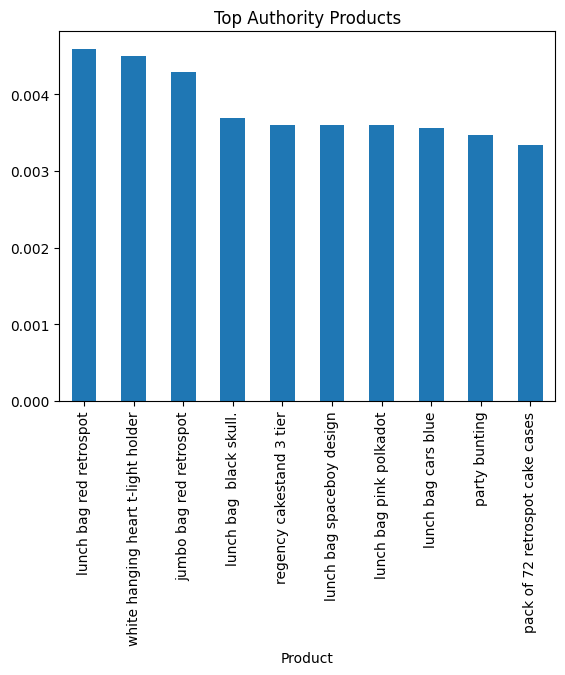

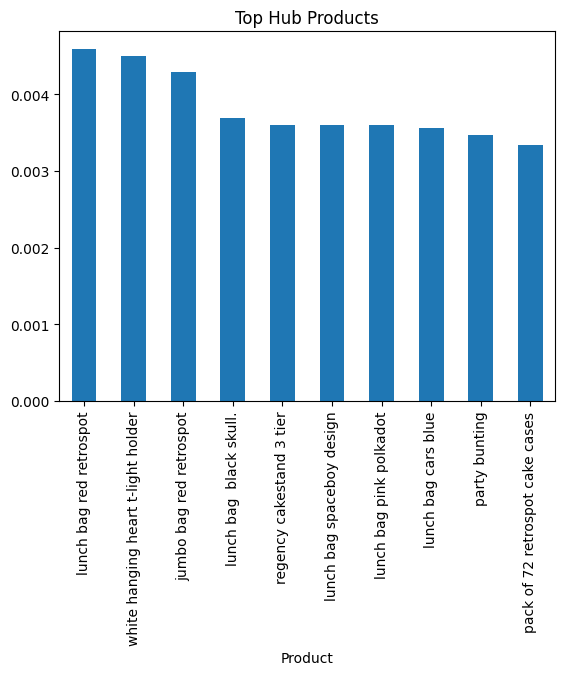

In [ ]:
import matplotlib.pyplot as plt

# =========================
# HITS Visualization
# =========================

top_authorities.head(10).set_index('Product')[
    'AuthorityScore'
].plot(kind='bar')

plt.title("Top Authority Products")
plt.show()


top_hubs.head(10).set_index('Product')[
    'HubScore'
].plot(kind='bar')

plt.title("Top Hub Products")
plt.show()

In [ ]:
hubs, authorities = nx.hits(G)

In [ ]:
hits_df = pd.DataFrame({
    'Product': list(hubs.keys()),
    'HubScore': list(hubs.values()),
    'AuthorityScore': list(authorities.values())
})

hits_df = hits_df.sort_values(
    by='AuthorityScore',
    ascending=False
)

print(hits_df.head(10))

                                 Product  HubScore  AuthorityScore
73               lunch bag red retrospot  0.004591        0.004591
5     white hanging heart t-light holder  0.004505        0.004505
136              jumbo bag red retrospot  0.004294        0.004294
272              lunch bag  black skull.  0.003687        0.003687
521             regency cakestand 3 tier  0.003605        0.003605
248            lunch bag spaceboy design  0.003600        0.003600
214              lunch bag pink polkadot  0.003597        0.003597
274                  lunch bag cars blue  0.003556        0.003556
1380                       party bunting  0.003470        0.003470
58       pack of 72 retrospot cake cases  0.003334        0.003334


In [ ]:
recommendations = list(G.neighbors(
    'white hanging heart t-light holder'
))

print(recommendations[:10])

['glass star frosted t-light holder', 'set 7 babushka nesting boxes', 'white metal lantern', 'cream cupid hearts coat hanger', 'knitted union flag hot water bottle', 'red woolly hottie white heart.', 'wooden frame antique white', 'retro coffee mugs assorted', 'wooden picture frame white finish', 'save the planet mug']


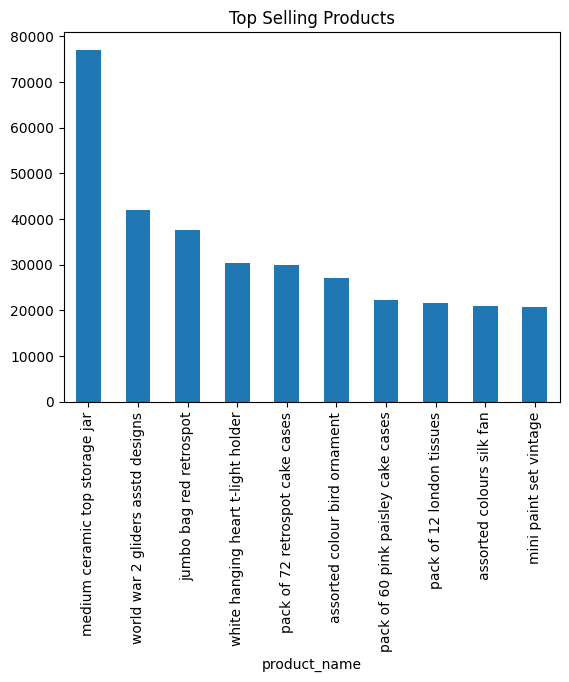

In [ ]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.show()

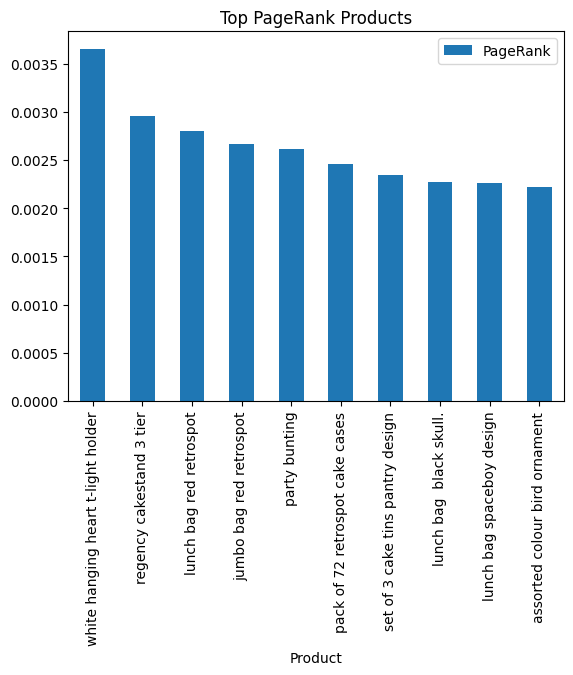

In [ ]:
pagerank_df.head(10).set_index('Product')\
.plot(kind='bar')

plt.title("Top PageRank Products")
plt.show()

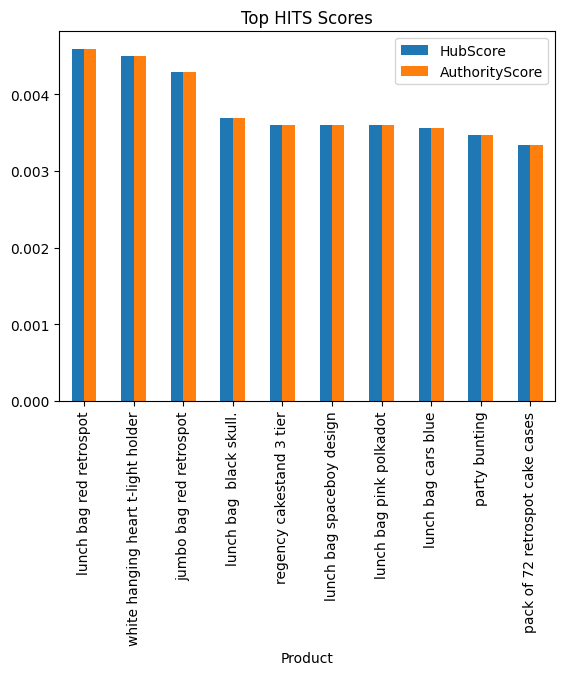

In [ ]:
hits_df.head(10).set_index('Product')\
[['HubScore', 'AuthorityScore']]\
.plot(kind='bar')

plt.title("Top HITS Scores")
plt.show()

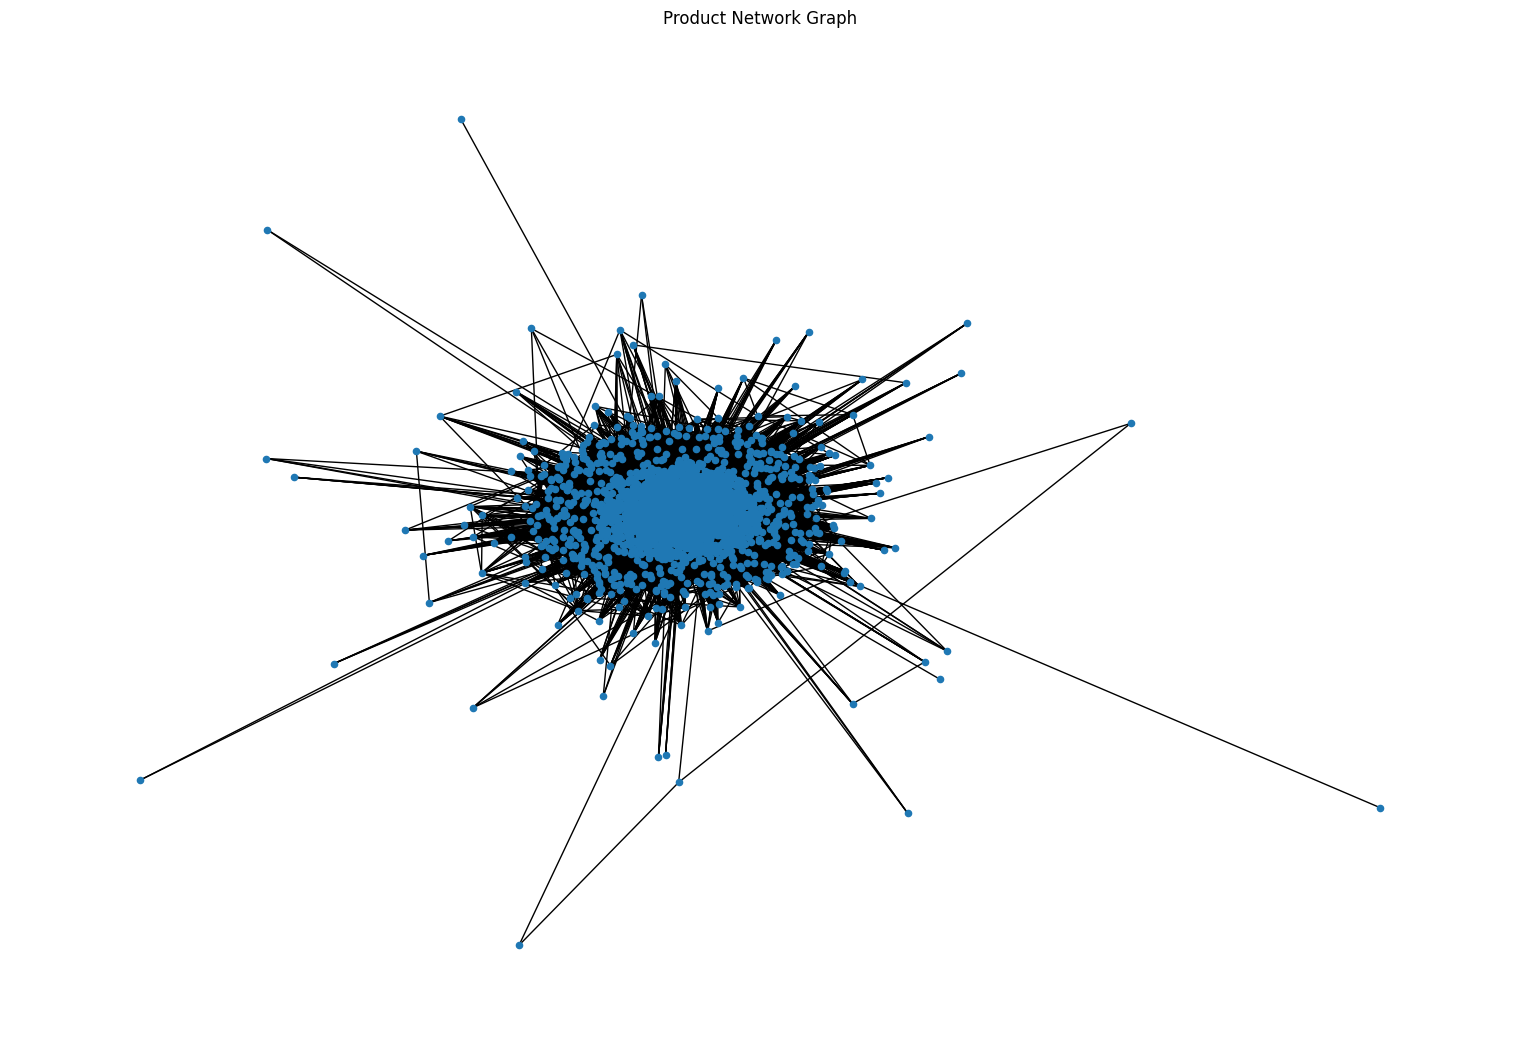

In [ ]:
plt.figure(figsize=(15,10))
nx.draw(G, node_size=20, with_labels=False)
plt.title("Product Network Graph")
plt.show()

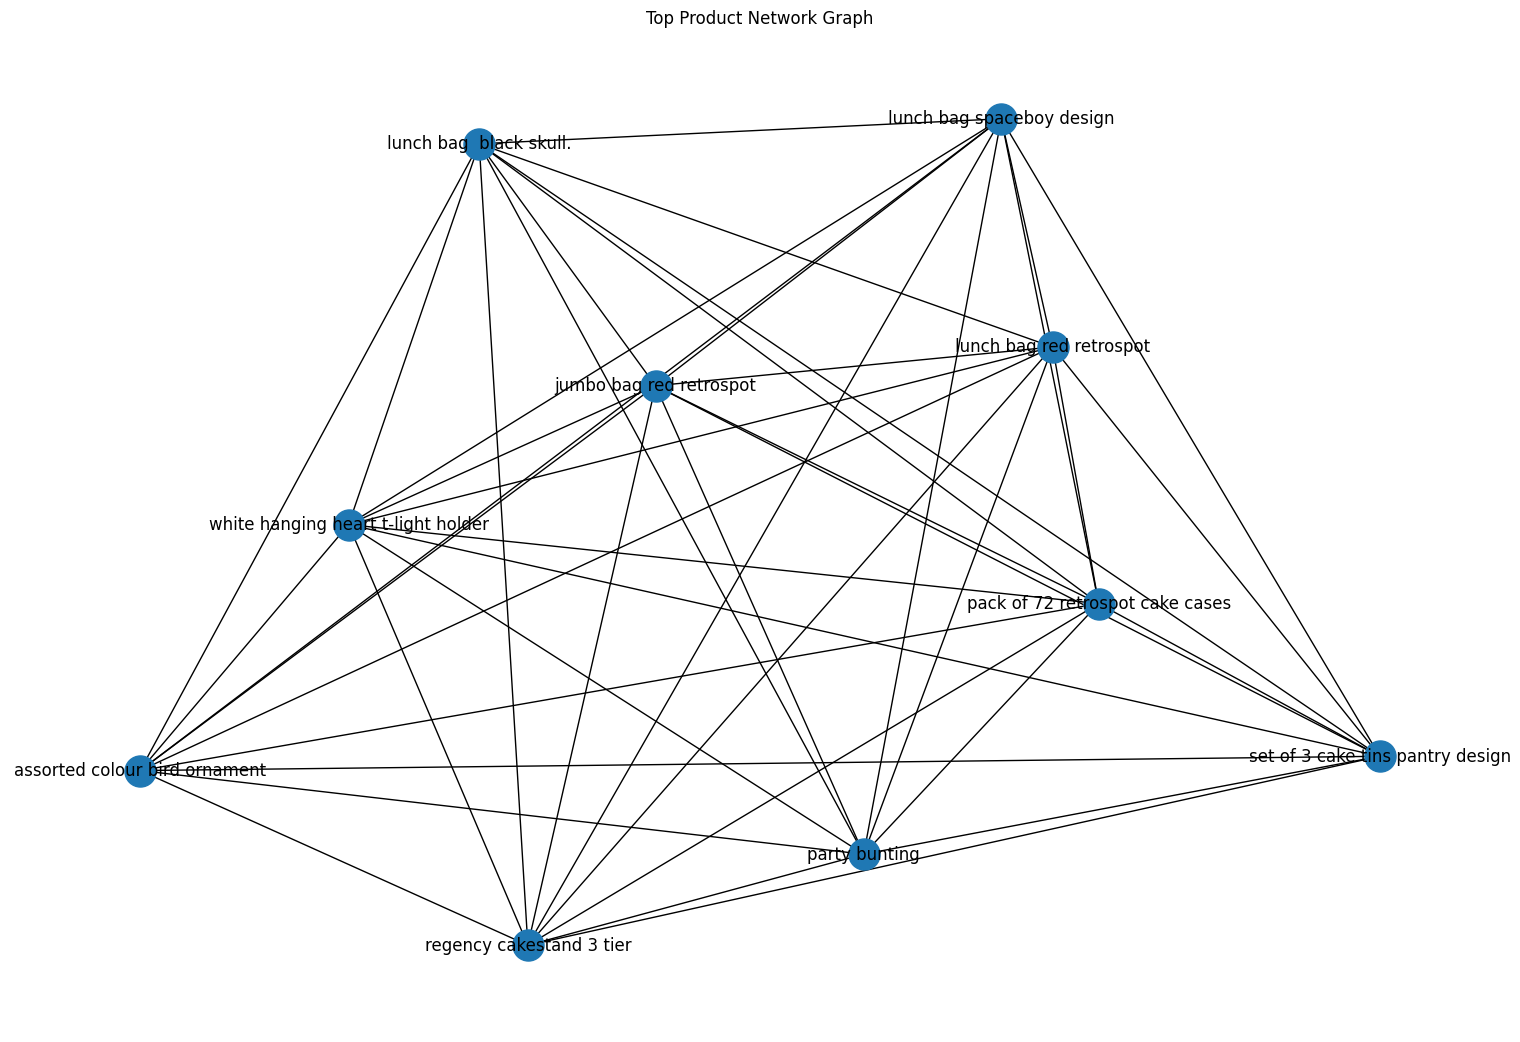

In [ ]:
top_nodes = pagerank_df.head(10)['Product']

subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(15,10))

nx.draw(
    subgraph,
    with_labels=True,
    node_size=500
)

plt.title("Top Product Network Graph")
plt.show()

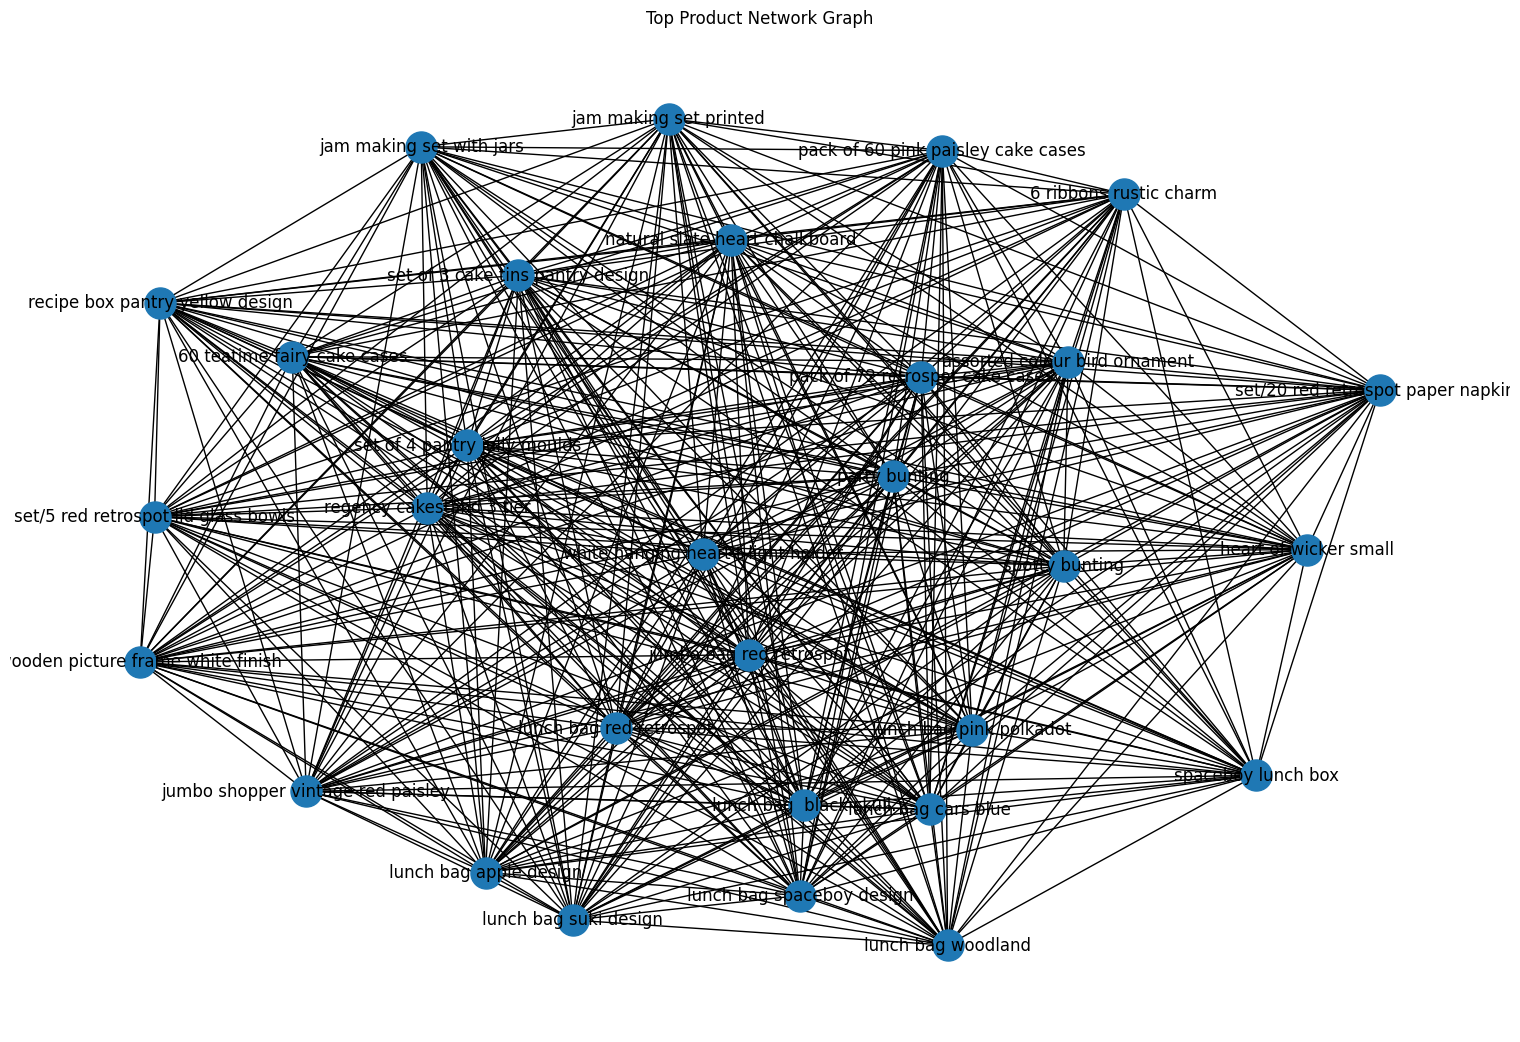

In [ ]:
top_nodes = pagerank_df.head(30)['Product']

subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(15,10))

nx.draw(
    subgraph,
    with_labels=True,
    node_size=500
)

plt.title("Top Product Network Graph")
plt.show()